In [204]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
        LSTM, 
        Dense,
        Dropout)
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [205]:
dataset_name="oil"

In [206]:
df = pd.read_csv(
    f"../data/after_f_Eng/{dataset_name}_F_Eng.csv"
)

In [207]:
data = df[["Close"]]

In [208]:
scaler = MinMaxScaler()

In [209]:
scaled_data = scaler.fit_transform(
    data
)

In [210]:
X = []
y = []

In [211]:
sequence_length = 30

In [212]:
for i in range(
    sequence_length,
    len(scaled_data)
):

    X.append(
        scaled_data[
            i-sequence_length:i
        ]
    )

    y.append(
        scaled_data[i]
    )

In [213]:
X = np.array(X)
y = np.array(y)

In [214]:
print(X.shape)
print(y.shape)

(6305, 30, 1)
(6305, 1)


In [215]:
split_index = int(
    len(X) * 0.8
)

In [216]:
X_train = X[:split_index]
y_train = y[:split_index]

In [217]:
X_test = X[split_index:]
y_test = y[split_index:]

In [218]:
print(X_train.shape)
print(X_test.shape)

(5044, 30, 1)
(1261, 30, 1)


In [219]:
model = Sequential()
model.add(
    LSTM(
        units=50,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

c:\Users\Maria\Documents\Projects\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [220]:
model.add(
    Dropout(0.2)
)

In [221]:
model.add(
    LSTM(
        units=50
    )
)

In [222]:
model.add(
    Dropout(0.2)
)

In [223]:
model.add(
    Dense(1)
)

In [224]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [225]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [226]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.0104 - val_loss: 8.2407e-04
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0023 - val_loss: 9.7699e-04
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0016 - val_loss: 7.1181e-04
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0016 - val_loss: 9.0060e-04
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0015 - val_loss: 6.4872e-04
Epoch 7/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0014 - val_loss: 6.3989e-04
Epoch 8/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0013 - val_loss: 6.3195e-04
Epoch 9/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 10/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0013 - val_loss: 7.0041e-04
Epoch 11/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0012 - val_loss: 8.7934e-04
Epoch

In [227]:
predictions = model.predict(
    X_test
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [228]:
predictions = scaler.inverse_transform(
    predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)

In [229]:
lstm_pred_df = pd.DataFrame({
    "Actual": y_test_actual.flatten(),
    "Predicted": predictions.flatten()
})

In [230]:
lstm_mae = mean_absolute_error(
    y_test_actual,
    predictions
)
lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)
lstm_r2 = r2_score(
    y_test_actual,
    predictions
)

In [231]:
print("LSTM Results for", dataset_name)
print()

print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("R2:", lstm_r2)

LSTM Results for oil

MAE: 1.9690268612286108
RMSE: 2.784801598744591
R2: 0.9701239990569691


In [232]:
lstm_results = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [lstm_mae],
    "RMSE": [lstm_rmse],
    "R2": [lstm_r2]
})

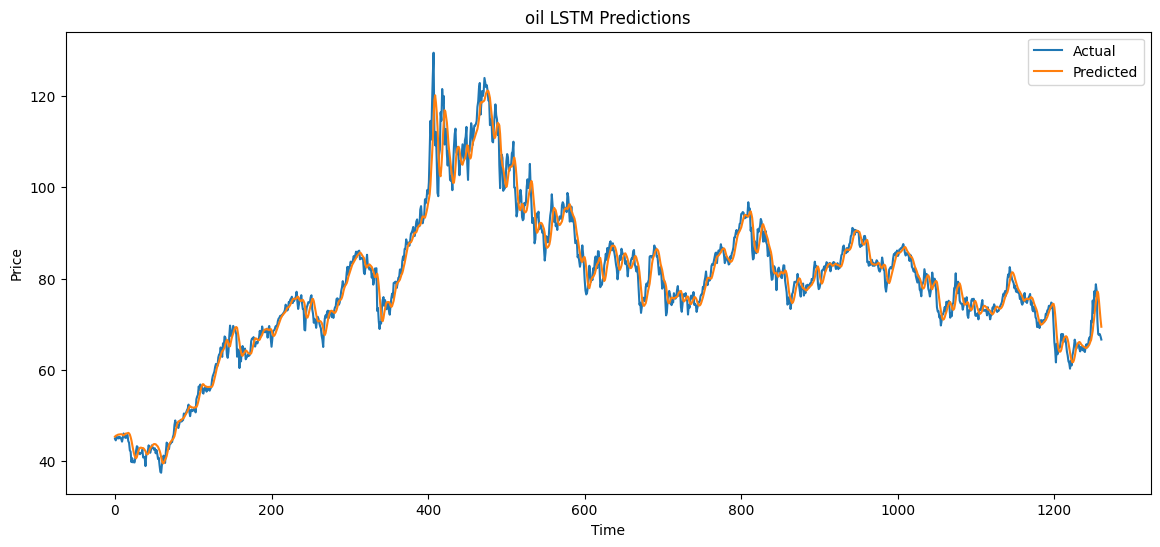

In [233]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.title(
    f"{dataset_name} LSTM Predictions"
)

plt.xlabel("Time")

plt.ylabel("Price")

plt.legend()

plt.show()

In [234]:
lstm_results.to_csv(
    f"../results/{dataset_name}/{dataset_name}_lstm_results.csv",
    index=False
)

In [235]:
model.save(
    f"../models/{dataset_name}/{dataset_name}_lstm.h5"
)

In [236]:
lstm_pred_df.to_csv(
    f"../results/{dataset_name}/{dataset_name}_lstm_predictions.csv",
    index=False
)